In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
daveianhickey_2000_16_traffic_flow_england_scotland_wales_path = kagglehub.dataset_download('daveianhickey/2000-16-traffic-flow-england-scotland-wales')

print('Data source import complete.')


100%|██████████| 132M/132M [00:02<00:00, 68.1MB/s]

Extracting files...


Data source import complete.


# United Kingdom traffic accidents - Exploratory Data Analysis
    18/03/2022
Welcome back!

Today I want to have a look at this amazing dataset I've found. It contains over 1.5 Million traffic accidents ocurring in the UK, and I hope we can get some cool and interesting insights from it.

As per usual, will follow the six steps of the Data Analysis process:
* [Ask](#ask)
* [Prepare](#prepare)
* [Process](#process)
* [Analyze](#analyze)
* [Share](#share)
* [Act](#act)

<a id="ask"></a>
## 1. Ask
### *What is it that I want to achieve with my analysis?*
Normally, we would first have a problem or question we want to solve and then we would think of the data needed to answer it. In this case we did the opposite haha. We found a dataset in Kaggle to perform EDA on, so this time we have to first look at the dataset and think of insights we could get from it. As we will see later, this dataset has lots of information regarding traffic accidents, this way, we will be trying to figure out:

* [Where do most car accidents occur](#where)
* [When do most car accidents occur](#when)
    - Have car accidents distributions varied in any way over the years?
* [Road conditions in accidents](#conditions)
    - Road type
    - Weather conditions
    - Light conditions
    - Speed limit

I would have also liked to look into *casualties* (fatal vs non-fatal) but as we will see [later](#casualties), column isn't consistent. A column featuring whether there was *alcohol/substances* involved in an accident would have been very interesting too.

<a id="prepare"></a>
## 2. Prepare
### *What data would help me answer those questions?*
As I just said in the paragraph above, this time we took the steps backwards. We found [this](https://www.kaggle.com/datasets/daveianhickey/2000-16-traffic-flow-england-scotland-wales) amazing dataset which has so much info about accidents in the UK, from years 2005 up to 2014 (skipping 2008 for unknown reasons).

In the hyperlink provided all the information regarding the dataset (License, Content and Acknowledgements among others) can be found.

## 3. Process
### *Getting Data ready for exploration*

### Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid") # Setting style for all graphs
%matplotlib inline

import datetime as dt

import warnings
warnings.filterwarnings('ignore')

### Loading Datasets and merging them together

In [ ]:
import os

# Construct the full paths to the CSV files using the downloaded dataset path
base_path = daveianhickey_2000_16_traffic_flow_england_scotland_wales_path
df_2005_2007 = pd.read_csv(os.path.join(base_path, "accidents_2005_to_2007.csv"))
df_2009_2011 = pd.read_csv(os.path.join(base_path, "accidents_2009_to_2011.csv"))
df_2012_2014 = pd.read_csv(os.path.join(base_path, "accidents_2012_to_2014.csv"))
# seems like we don't have 2008 data

accidents = pd.concat([df_2005_2007, df_2009_2011,df_2012_2014], axis=0)

In [ ]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1504150 entries, 0 to 464696
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1504150 non-null  object 
 1   Location_Easting_OSGR                        1504049 non-null  float64
 2   Location_Northing_OSGR                       1504049 non-null  float64
 3   Longitude                                    1504049 non-null  float64
 4   Latitude                                     1504049 non-null  float64
 5   Police_Force                                 1504150 non-null  int64  
 6   Accident_Severity                            1504150 non-null  int64  
 7   Number_of_Vehicles                           1504150 non-null  int64  
 8   Number_of_Casualties                         1504150 non-null  int64  
 9   Date                                         1504150

In [ ]:
accidents.head()

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


### Data cleaning and feature engineering

In [ ]:
selRows = accidents[accidents['Time'].isna()].index
accidents = accidents.drop(selRows, axis=0)
accidents["Time"] = pd.to_datetime(accidents["Time"], format='%H:%M')
accidents["Hour"] = accidents["Time"].dt.hour


#accidents["Date"] = pd.to_datetime(accidents["Date"], format="%d/%m/%Y")
accidents["Month"] = pd.DatetimeIndex(accidents["Date"]).month

<a id="casualties"></a>

In [ ]:
accidents["Number_of_Casualties"].unique()

# It was supposed to contain only values 1: Fatal, 2: Serious, 3: Slight
# Sadly won't be able to analyze it

array([ 1,  2,  5,  4,  3,  8,  7,  6, 10,  9, 23, 17, 13, 11, 19, 15, 16,
       12, 14, 18, 20, 29, 21, 35, 22, 26, 45, 41, 36, 40, 25, 28, 42, 68,
       27, 48, 24, 43, 87, 63, 51, 33, 38, 46, 70, 93, 54])

,Features,MissingPercent
4,Junction_Detail,100.000000
11,Carriageway_Hazards,98.188636
10,Special_Conditions_at_Site,97.568157
5,Junction_Control,40.076830
13,LSOA_of_Accident_Location,7.190065
12,Did_Police_Officer_Attend_Scene_of_Accident,0.194236
9,Road_Surface_Conditions,0.129934
8,Weather_Conditions,0.008379
0,Location_Easting_OSGR,0.006716
1,Location_Northing_OSGR,0.006716


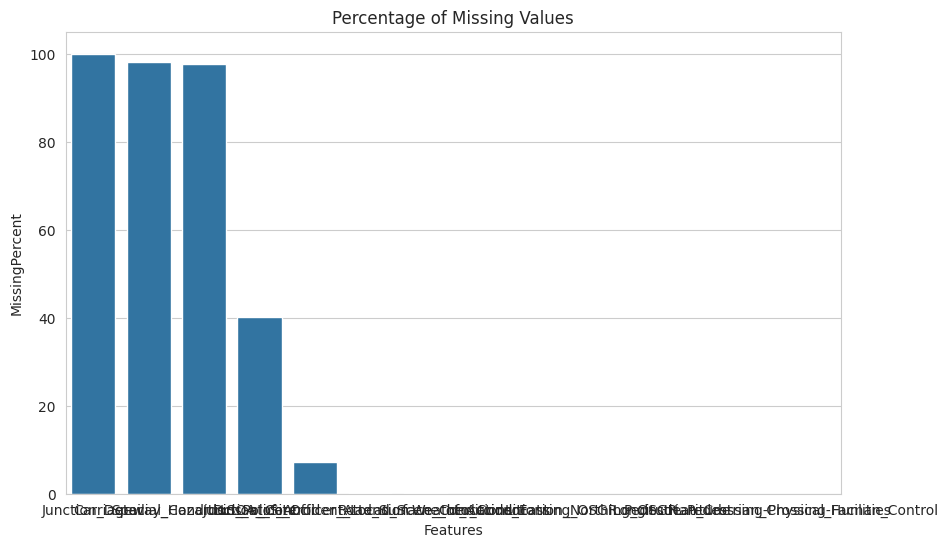

In [ ]:
# Function showing missing values in each column
def get_missings(df):
    labels,values = list(),list()
    if df.isna().sum().sum()>0:
        for column in df.columns:
            if df[column].isnull().sum():
                labels.append(column)
                values.append((df[column].isnull().sum() / len(df[column]))*100)

                #Make a dataframe
        missings=pd.DataFrame({'Features':labels,'MissingPercent':values }).sort_values(by='MissingPercent',ascending=False)
        plt.figure(figsize=(10,6))
        sns.barplot(x=missings.Features,y=missings.MissingPercent).set_title('Percentage of Missing Values')
        return missings
    else:
        return False

get_missings(accidents)

The columns with a big amount of missing data won't be used in our analysis. Other features have a very *little amount* of missing data (<1%), so we will just keep it that way.

In [ ]:
accidents_peryear = {}

years = ['2005', '2006', "2007", "2009", "2010", "2011", "2012", "2013", "2014"]
for year in years:
    accidents_peryear[year] = accidents[accidents["Year"]==int(year)]

accidents_perdow = {}

dow = {1:"Monday", 2:"Tuesday", 3:"Wednesday", 4:"Thursday", 5:"Friday", 6:"Saturday", 7:"Sunday"}
for key in dow:
    accidents_perdow[dow[key]] = accidents[accidents["Day_of_Week"]==key]

months = {1: "Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun", 7:"Jul", 8:"Ag", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}

In [ ]:
# for whatever reason, year 2007 doens't seem to be sorted by date
print("Before:", accidents_peryear["2007"]["Month"].unique())

accidents_peryear["2007"] = accidents_peryear["2007"].sort_values("Month")
print("After:", accidents_peryear["2007"]["Month"].unique())

Before: [ 5  2  8  3  9 10 12  1 11  6  7  4]
After: [ 1  2  3  4  5  6  7  8  9 10 11 12]


<a id="analyze"></a> <a id="share"></a> <a id="where"></a>
## 4. Analyze & 5. Share
### *Getting insights and sharing them with the world*
We will be doing both steps at once, because as we all know most of the times the best way to analyze and gain insights from data is through visualization.

Here we will try to answer the questions from the *Ask* phase while trying to present the info as clearly as possible.

## Where do most accidents occur?
### Accidents Density Graph

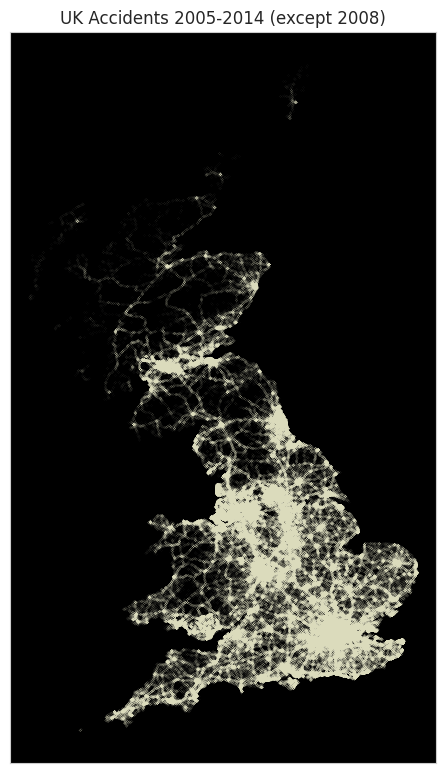

In [ ]:
plt.figure(figsize=(5.5,9.5))
plt.axes().set_facecolor("black")
plt.scatter(x = accidents["Longitude"], y = accidents["Latitude"],s=0.005, alpha= 0.25, color="lightyellow")
plt.title("UK Accidents 2005-2014 (except 2008)")
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

Looks like most accidents happen, as could be expected; in big cities around **London**, **Liverpool** and the **Midlands**, and around *Newcastle* and *Middlesbrough* in the **North East**. Meanwhile in *Scotland* there's a big concentration as well, between **Glasgow** and **Edinburgh**. In *Wales*, most accidents occur near the capital, **Cardiff**.

Comparing countries in the UK (or Great Britain, I don't think there's data from Nothern Ireland), most accidents seem to take place in **England**. We should also keep in mind there is where most trips happen. It's probably not that English drivers don't how to drive. It's more likely that there is a higher chance to suffer an accident when there's more traffic. This same logic can be applied throughout the whole analysis.

<a id="when"></a>
## When do most car accidents occur?
### Accidents over the years

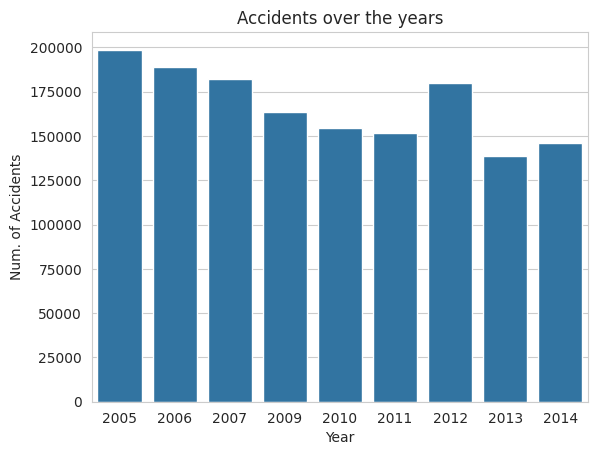

Mean:167093.22   Standard Deviation:21002.18


In [ ]:
sns.barplot(x=accidents.Year.value_counts().index,y=accidents.Year.value_counts())
plt.ylabel("Num. of Accidents")
plt.title("Accidents over the years")

plt.show()

print("Mean:{:.2f}   Standard Deviation:{:.2f}".format(accidents.Year.value_counts().mean(),
                                                      accidents.Year.value_counts().std()))

We can see the amount of traffic accidents has diminished over the years, displaying a **downwards trend with a rare increase in year 2012**. We would need more information to know exactly what caused this. Maybe the *London 2012 Olympics* and *Paralympics* had something to do with it.

During this years, they **averaged** *167,127.78* accidents, with a **Standard Deviation** of *21,006.79*.

### Accidents each month

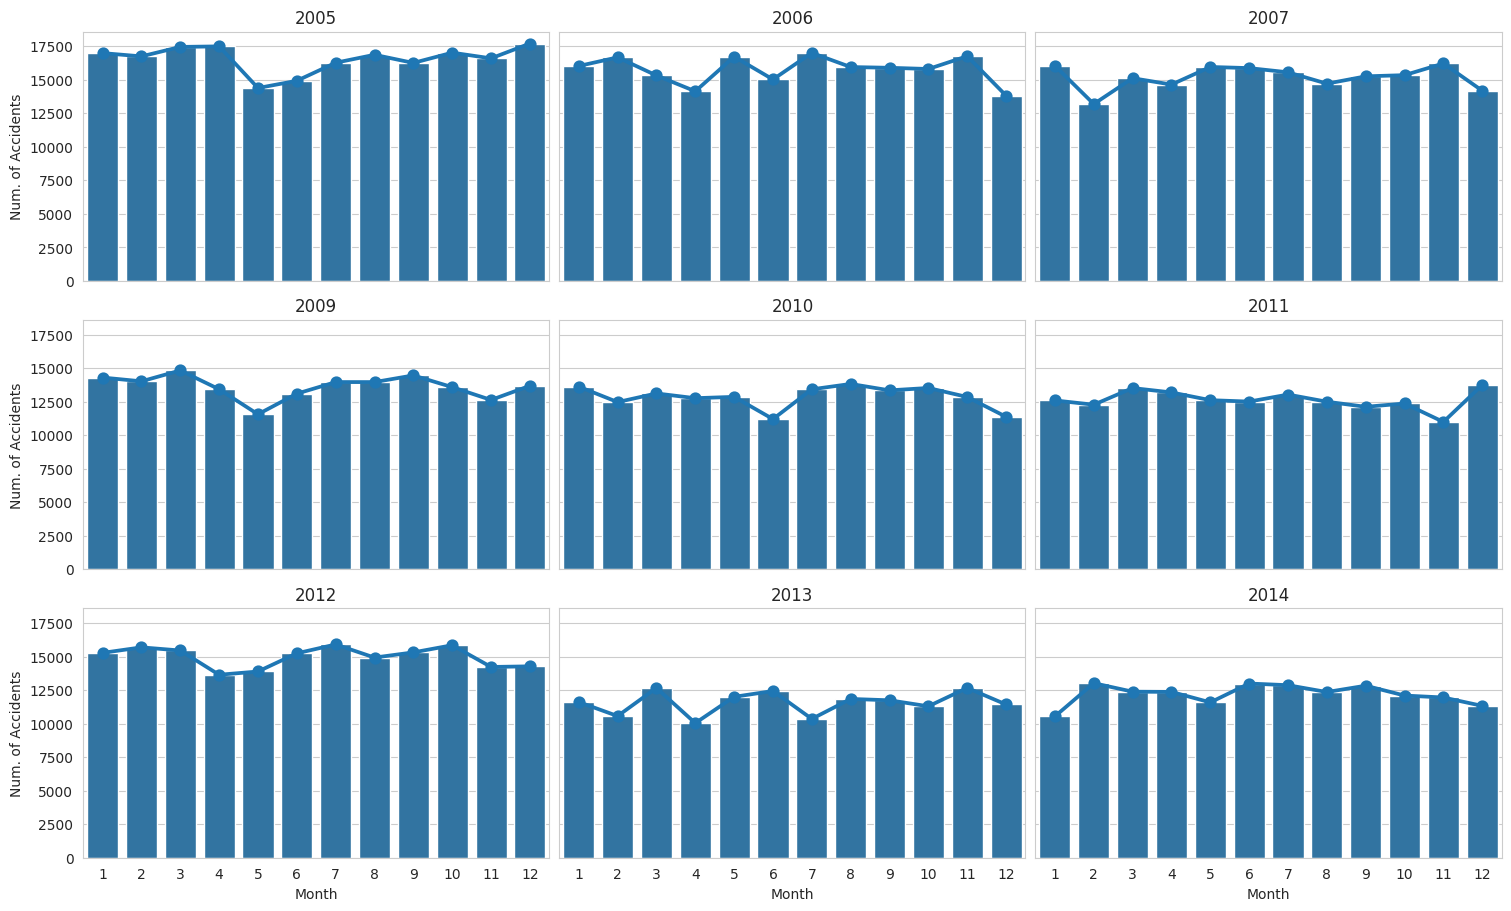

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=True, constrained_layout=True, figsize=(15,9))
year = 2004

for row in range(axs.shape[0]):
    for col in range(axs.shape[1]):
        year += 1
        if year == 2008: year = 2009
        sns.barplot(ax=axs[row][col],x=accidents_peryear[str(year)]["Month"].unique(),
                    y=accidents_peryear[str(year)].groupby("Month")["Year"].count())
        sns.pointplot(ax=axs[row][col],x=accidents_peryear[str(year)]["Month"].unique(),
                     y=accidents_peryear[str(year)].groupby("Month")["Year"].count())
        axs[row][col].set_ylabel("Num. of Accidents")
        axs[row][col].set_xlabel("Month")
        axs[row][col].set_title(str(year))

fig.show()

Here we can see again that there's just much more volume overall in 2012, not an eventual peak. Trends however, seem fairly similar.

**October** and **November** are consistently the months with most accidents

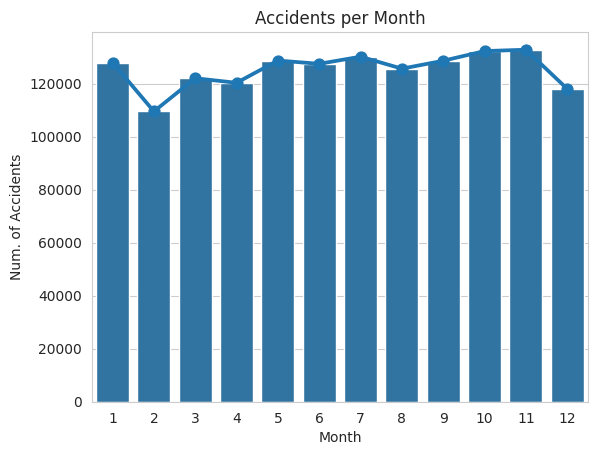


Mean:125319.92   Standard Deviation:6747.99



Month,1,2,3,4,5,6,7,8,9,10,11,12
Num. of Accidents,127974,109540,122059,120333,128738,127500,130196,125667,128656,132310,132815,118051


In [ ]:
# Temporary df for viz
dfmonth = pd.DataFrame(accidents.groupby("Month")["Year"].count())
dfmonth = dfmonth.rename({"Year":"Num. of Accidents"}, axis=1)

sns.barplot(x = dfmonth.index, y = dfmonth["Num. of Accidents"])
sns.pointplot(x=dfmonth.index,y=dfmonth["Num. of Accidents"])
plt.title("Accidents per Month")
plt.show()

print("\nMean:{:.2f}   Standard Deviation:{:.2f}\n".format(float(dfmonth.mean().unique()), float(dfmonth.std().unique())))
dfmonth.T

On **average** a month has *125,345.83* accidents, with a **Standard Deviation** of *8,280.73*.

### Accidents per hour of the day

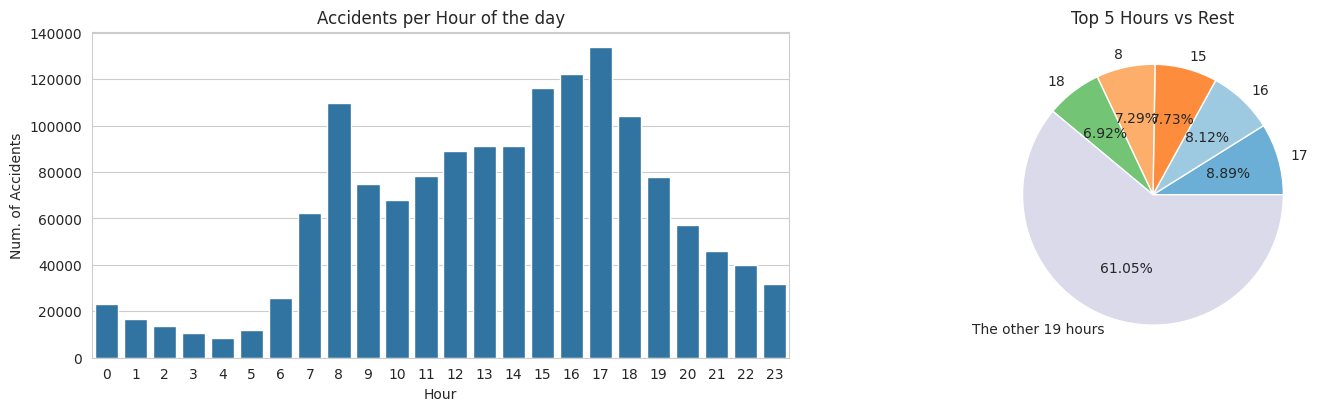


Mean:62659.96   Standard Deviation:39438.75

      Num. of Accidents
Hour                   
17               133728
16               122117
15               116250
8                109608
18               104067 



Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Num. of Accidents,23024,16886,13616,10826,8347,12032,25831,62368,109608,74893,...,91251,116250,122117,133728,104067,77717,57208,45746,39886,31875


In [ ]:
df = pd.DataFrame(accidents.groupby("Hour")["Year"].count())
df = df.rename({"Year":"Num. of Accidents"}, axis=1)
top5hours = pd.DataFrame(df["Num. of Accidents"].nlargest(5))
elsehours = pd.DataFrame(data = {'Hour':'The other 19 hours',
                                 'Num. of Accidents':[df["Num. of Accidents"].nsmallest(19).sum()]})

elsehours.set_index("Hour", inplace=True)
topvsothers = pd.concat([top5hours, elsehours])


fig, axs = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(15,4))

sns.barplot(ax=axs[0], x = df.index, y = df["Num. of Accidents"])
axs[0].set_title("Accidents per Hour of the day")

cmap = plt.get_cmap("tab20c")
colors = cmap(np.array([1, 2, 5, 6, 9,15]))
axs[1].pie(topvsothers["Num. of Accidents"], labels=topvsothers.index, autopct='%1.2f%%',colors=colors)
axs[1].set_title("Top 5 Hours vs Rest")

plt.show()

print("\nMean:{:.2f}   Standard Deviation:{:.2f}\n".format(float(df.mean().unique()), float(df.std().unique())))
print(top5hours, "\n")
df.T

This could very well be a bar plot showing most traffic hours. Most accidents occur during day time, when there's **more traffic**. If we have a deeper look, we can see that *Top 3* hours and *Top 5* are between hours **15:00 - 18:59**. *Top 4* being **8:00 - 8:59**. These *5 hours make up for almost 40%* of the accidents.

We also have a **mean** value of *62,659.96* accidents per hour, with a **Standard Deviation** of *39,438.75*. Obviously, a much more spread distribution than between different months.

### Quick sum up viz: *When do most car accidents occur?*

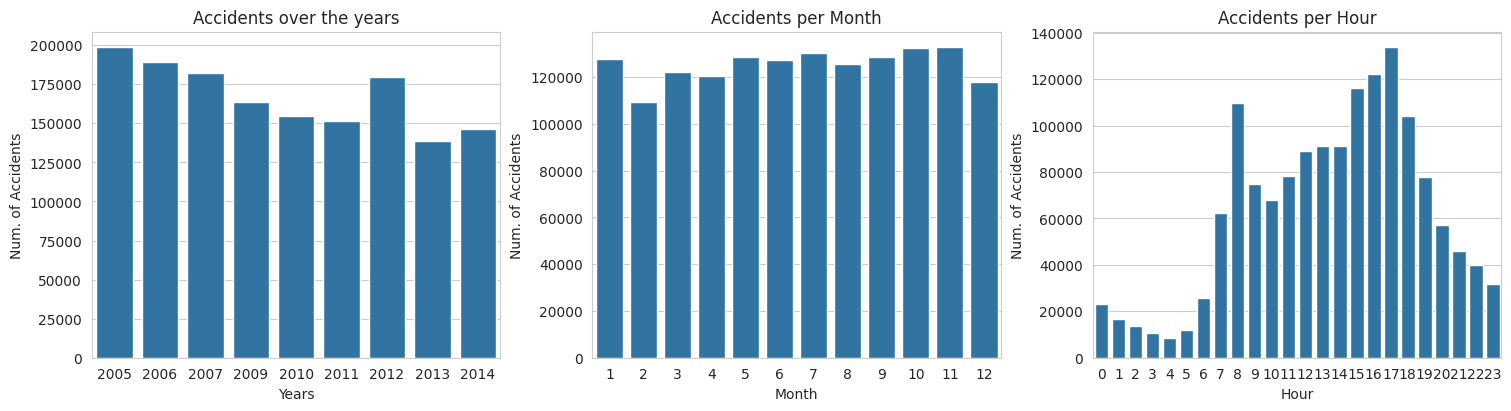


YEARLY - Mean:167093.22   Standard Deviation:21002.18

MONTHLY - Mean:125319.92   Standard Deviation:6747.99

HOURLY - Mean:62659.96   Standard Deviation:39438.75



In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, constrained_layout=True, figsize=(15,4))

sns.barplot(ax=axs[0], x=accidents.Year.value_counts().index,y=accidents.Year.value_counts())
axs[0].set_ylabel("Num. of Accidents")
axs[0].set_xlabel("Years")
axs[0].set_title("Accidents over the years")

sns.barplot(ax=axs[1], x = dfmonth.index, y = dfmonth["Num. of Accidents"])
axs[1].set_title("Accidents per Month")

sns.barplot(ax=axs[2], x = df.index, y = df["Num. of Accidents"])
axs[2].set_title("Accidents per Hour")

plt.show()

print("\nYEARLY - Mean:{:.2f}   Standard Deviation:{:.2f}".format(accidents.Year.value_counts().mean(),
                                                                  accidents.Year.value_counts().std()))
print("\nMONTHLY - Mean:{:.2f}   Standard Deviation:{:.2f}".format(float(dfmonth.mean().unique()),
                                                                    float(dfmonth.std().unique())))
print("\nHOURLY - Mean:{:.2f}   Standard Deviation:{:.2f}\n".format(float(df.mean().unique()), float(df.std().unique())))

**Downwards trend over the years** (**2012** exception). Most accidents occurring in **November and October**, as well as **15:00 - 18:59** and **8:00 - 8:59**.

<a id="conditions"></a>
## Road conditions affecting accidents?
### Road type

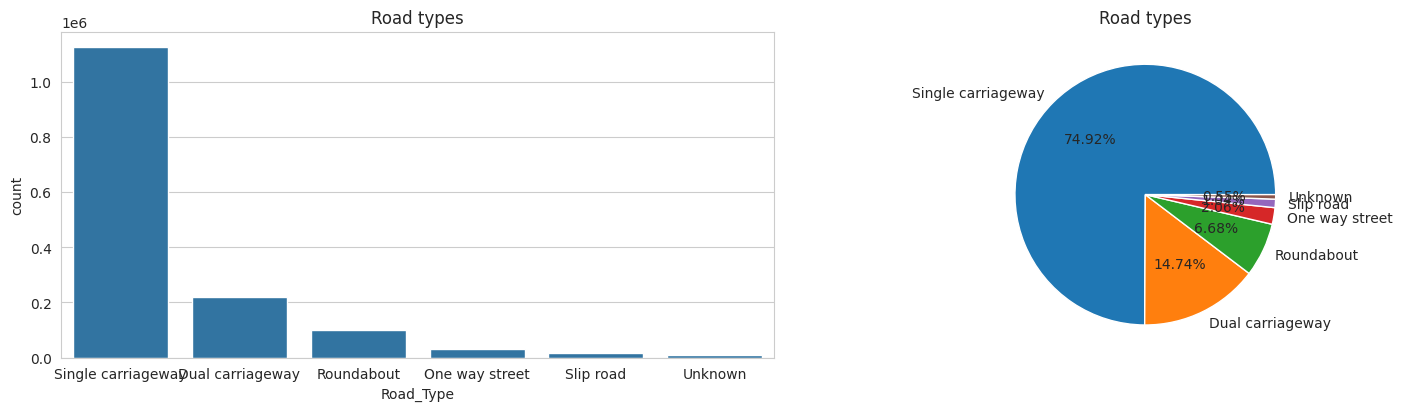

,count
Road_Type,
Single carriageway,1126701
Dual carriageway,221707
Roundabout,100449
One way street,30973
Slip road,15666
Unknown,8343


In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(15,4))
road = accidents["Road_Type"].value_counts()

sns.barplot(ax=axs[0], x = road.index, y = road)
axs[0].set_title("Road types")

axs[1].pie(road, labels=road.index, autopct='%1.2f%%')
axs[1].set_title("Road types")

plt.show()

road

**Single carriageway** is by far the road type with most accidents. I think **Roundabouts** should also be mentioned, I don't think there are that many of them, still many accidents seem to occur around them.

### Weather conditions

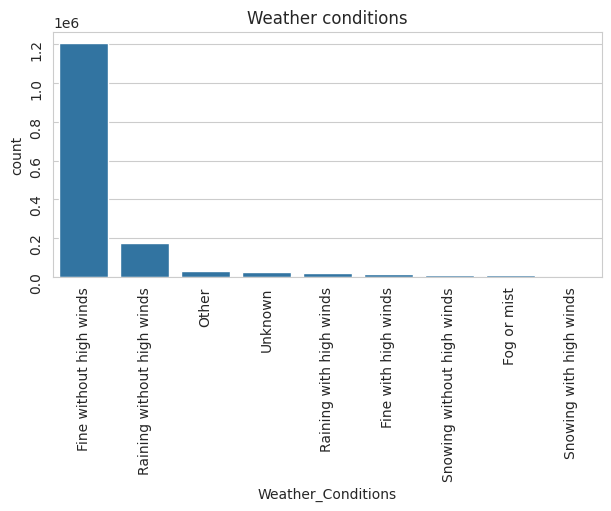

,count
Weather_Conditions,
Fine without high winds,1203705
Raining without high winds,177626
Other,33495
Unknown,28280
Raining with high winds,20808
Fine with high winds,18352
Snowing without high winds,11299
Fog or mist,8188
Snowing with high winds,1960


In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=1, constrained_layout=True, figsize=(6,5))
weather = accidents["Weather_Conditions"].value_counts()

sns.barplot(ax=axs, x = weather.index, y = weather)
axs.set_title("Weather conditions")
axs.tick_params(labelrotation=90)


plt.show()

weather

This doens't say much. We don't know exactly the times it was raining or there were high winds, so **we can't** really **tell if a given weather condition is affecting accidents** much or not.

### Light conditions

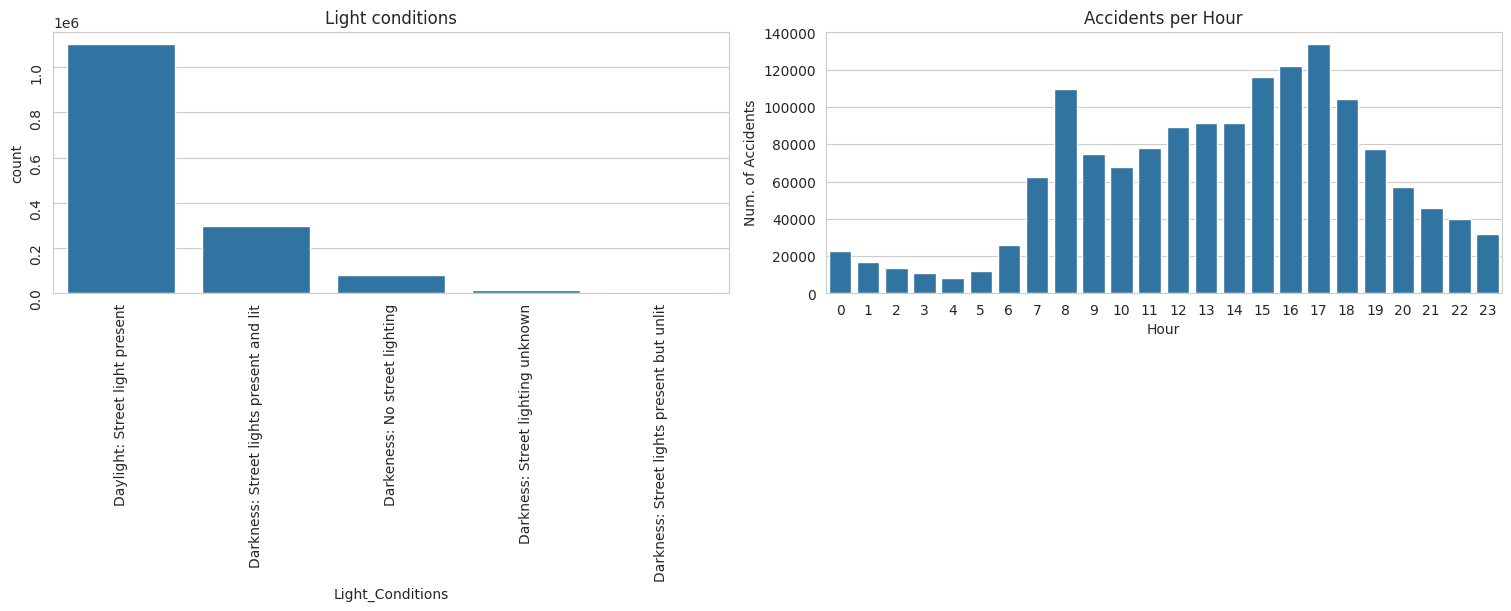

,count
Light_Conditions,
Daylight: Street light present,1102015
Darkness: Street lights present and lit,296274
Darkeness: No street lighting,82537
Darkness: Street lighting unknown,16109
Darkness: Street lights present but unlit,6904


In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(15,6))
light = accidents["Light_Conditions"].value_counts()

sns.barplot(ax=axs[0], x = light.index, y = light)
axs[0].set_title("Light conditions")
axs[0].tick_params(labelrotation=90)

sns.barplot(ax=axs[1], x = df.index, y = df["Num. of Accidents"])
axs[1].set_title("Accidents per Hour")

plt.show()

light

Here again, we can see that most accidents occur during daytime, with day light. However, we would need the total number of trips during each condition to look for a correlation with accidents.

### Speed limit

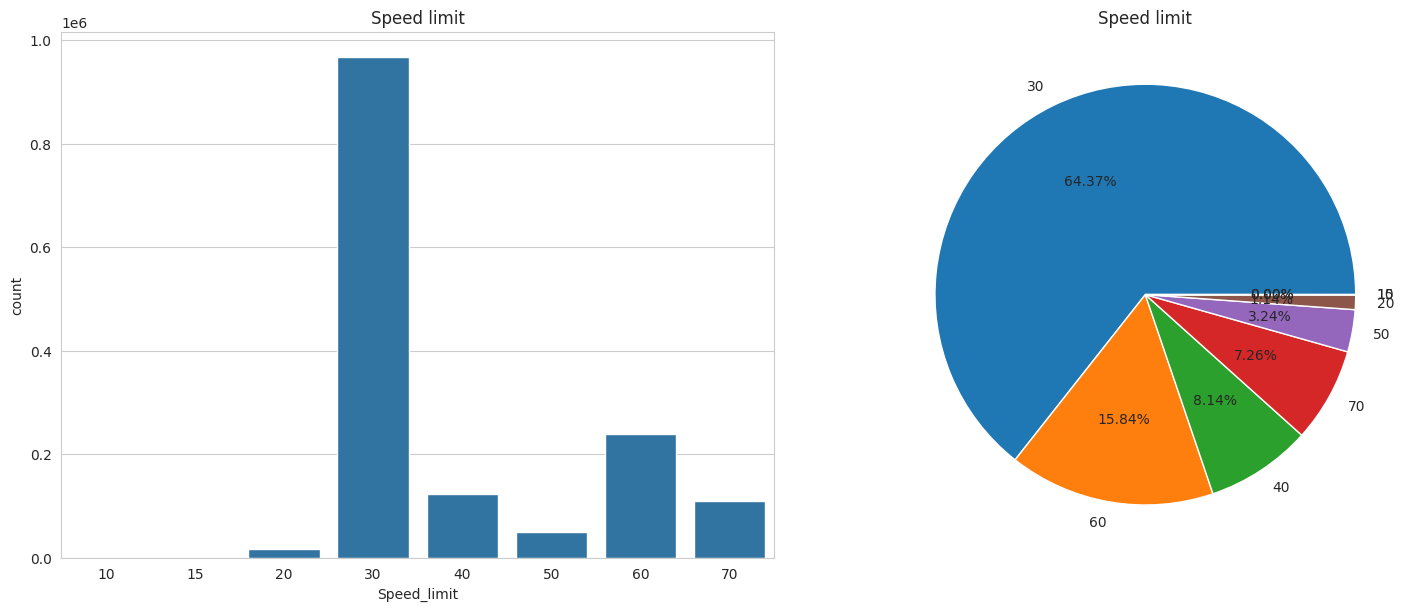

,count
Speed_limit,
30,968094
60,238166
40,122376
70,109249
50,48778
20,17152
10,14
15,10


In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(15,6))
speed = accidents["Speed_limit"].value_counts()

sns.barplot(ax=axs[0], x = speed.index, y = speed)
axs[0].set_title("Speed limit")

axs[1].pie(speed, labels=speed.index, autopct='%1.2f%%')
axs[1].set_title("Speed limit")

plt.show()

speed

**30 miles per hour** road sections are were more accidents occur. Same thing mentioned before, we need more data to look for correlations.

**NOTE: 1mph = 1.60934 km/h**

### Quick sum up viz: *Road conditions: Affecting accidents?*

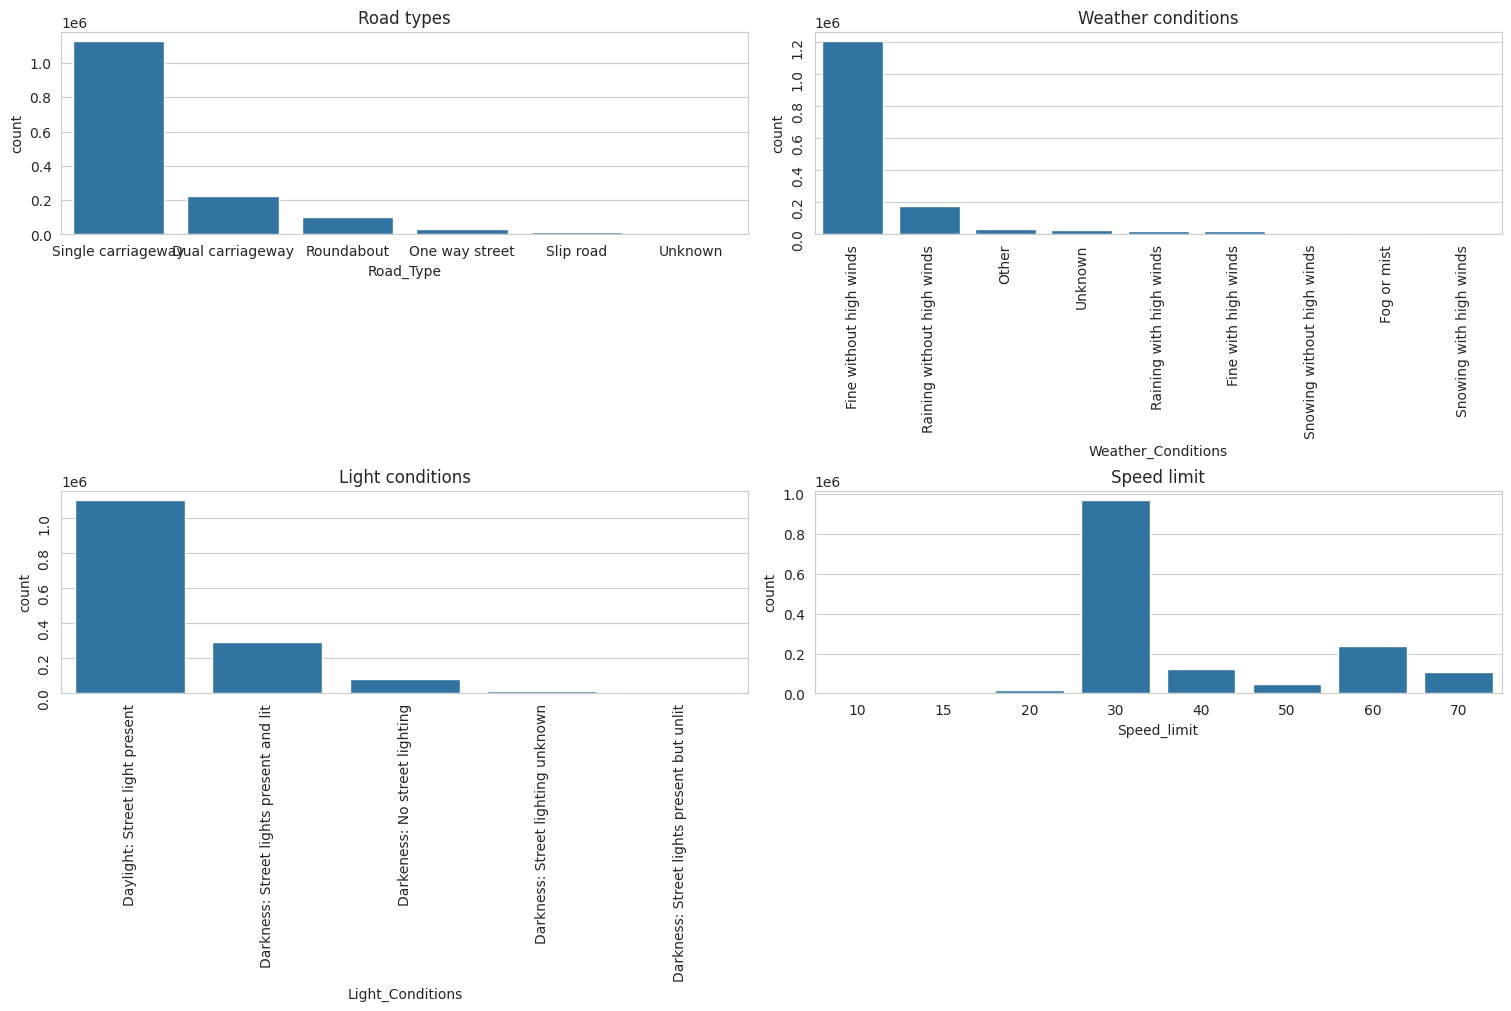

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(15,10))

sns.barplot(ax=axs[0,0], x = road.index, y = road)
axs[0,0].set_title("Road types")

sns.barplot(ax=axs[0,1], x = weather.index, y = weather)
axs[0,1].set_title("Weather conditions")
axs[0,1].tick_params(labelrotation=90)

sns.barplot(ax=axs[1,0], x = light.index, y = light)
axs[1,0].set_title("Light conditions")
axs[1,0].tick_params(labelrotation=90)

sns.barplot(ax=axs[1,1], x = speed.index, y = speed)
axs[1,1].set_title("Speed limit")

plt.show()

**Single carriageway** is by far the road type with most accidents. **Roundabouts** would be interesting to look at.

We mentioned how not knowing the amount of total trips isn't helping us looking for correlations between conditions and number of accidents. So not much we can say from these graphs.

<a id="act"></a>
## 6. Act
### *What to do with all of this ?*

These were the questions we wanted to get insights about:
* Where do most car accidents occur
* When do most car accidents occur
    - Have car accidents distributions varied in any way over the years?
* Road conditions in accidents
    - Road type
    - Weather conditions
    - Light conditions
    - Speed limit
   
We looked at all of them, and some insights were more useful than others; many times due to the lack of more data.

However, I think we still got some cool graphs and information. To have a better look at all we got, I'm going to **SUM UP the SUM UPs** from each section !!
### [*Where do most car accidents occur?*](#where)
Looks like most accidents happen, as could be expected; in big cities around **London**, **Liverpool** and the **Midlands**, and around *Newcastle* and *Middlesbrough* in the **North East**. Meanwhile in *Scotland* there's a big concentration as well, between **Glasgow** and **Edinburgh**. In *Wales*, most accidents occur near the capital, **Cardiff**.

Comparing countries in the UK (or Great Britain, I don't think there's data from Nothern Ireland), most accidents seem to take place in **England**. We should also keep in mind there is where most trips happen. It's probably not that English drivers don't how to drive. It's more likely that there is a higher chance to suffer an accident when there's more traffic. This same logic can be applied throughout the whole analysis.
### [*When do most car accidents occur?*](#when)
**Downwards trend over the years** (**2012** exception). Most accidents occurring in **November and October**, as well as **15:00 - 18:59** and **8:00 - 8:59**.

### [*Road conditions: Affecting accidents?*](#conditions)
**Single carriageway** is by far the road type with most accidents. **Roundabouts** would be interesting to look at.

We mentioned how not knowing the amount of total trips isn't helping us looking for correlations between conditions and number of accidents. So not much we can say from these graphs.

*If anyone wants to look at the graphs in each section, I've provided hyperlinks to access them rapidly.*

<a id="Machine learning model"></a>
## 7. Machine learning model
In this section, I will apply a Machine Learning model to predict the severity of traffic accidents based on several features such as the hour of the accident and road characteristics. After preparing the dataset, the data will be split into training and testing sets. Then, a classification model will be trained to learn patterns in the data and make predictions. Finally, the model’s performance will be evaluated to measure how accurately it can predict accident severity.


In [ ]:
features = ["Hour","Speed_limit"]
X = accidents[features]
y = accidents["Accident_Severity"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.8507055271837429


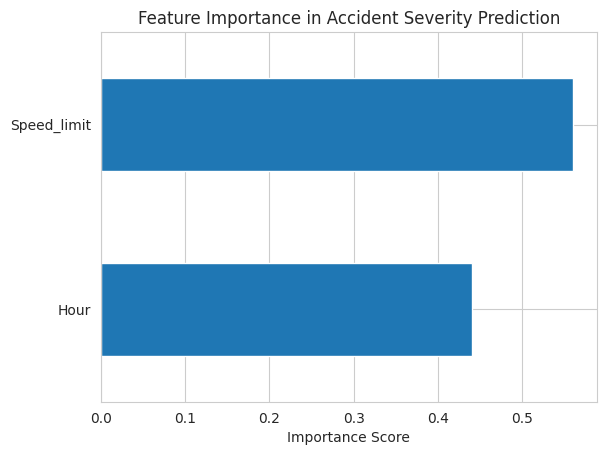

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance in Accident Severity Prediction")
plt.xlabel("Importance Score")
plt.show()

In this section, a machine learning model was trained to predict the severity of traffic accidents using selected features from the dataset. The model was able to learn patterns from the data and make predictions on unseen data. The results show that certain factors, such as the time of the accident and road characteristics, can influence accident severity. Although the model provides useful insights, further improvements could be achieved by including more relevant variables and experimenting with other machine learning algorithms.


# Thanks for reading!